In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Importing train, val, test dataset

In [2]:
folder_path = r'D:\Codes\Artificial_Intelligence\Machine_Learning\Scikit_Learn\Projects\Train_Val_Test_Ouptut'

X_train = pd.read_csv(fr'{folder_path}\X_train.csv').squeeze()
Y_train = pd.read_csv(fr'{folder_path}\Y_train.csv').squeeze()

X_val = pd.read_csv(fr'{folder_path}\X_test.csv').squeeze()
Y_val = pd.read_csv(fr'{folder_path}\Y_val.csv').squeeze()

test_df = pd.read_csv(r'D:\Codes\Artificial_Intelligence\Machine_Learning\Scikit_Learn\Projects\Datasets\flood_prediction\test.csv') # original test_df because test_input_df does not have id need for submission file
test_input_df = pd.read_csv(fr'{folder_path}\test_input_df.csv').squeeze()

print('Read successfully')

Read successfully


In [3]:
test_df = pd.read_csv(r'D:\Codes\Artificial_Intelligence\Machine_Learning\Scikit_Learn\Projects\Datasets\flood_prediction\test.csv')
print('Read test_df successfull')

Read test_df successfull


# Using K-Fold to create model from multiple models

In [4]:
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
import xgboost
import lightgbm as lgb
import catboost as cb

#------------ 1. Define Base Models ------------ 
models = {
    'xgbr': xgboost.XGBRegressor(random_state= 577,
                                n_estimators= 1000,
                                booster= 'gbtree',
                                learning_rate= 0.05,         # 0.05 is a sweet spot
                                max_depth= 9,
                                objective= 'reg:squarederror',
                                tree_method= 'hist',
                                device= 'cpu',               # Change to cuda if you have a GPU
                                gamma= 0.2,
                                min_child_weight= 12,
                                subsample= 0.9,
                                colsample_bytree= 0.8,
                                reg_alpha= 0.1,
                                reg_lambda= 1.0,
                                n_jobs= -1,
                                base_score= 0.5,
                                verbosity= 2
                            ),
    'lgbmr': lgb.LGBMRegressor(n_estimators=550,
                                random_state=980,
                                n_jobs=-1,
                                learning_rate=0.05,
                                subsample=0.9,
                                min_child_samples=7,
                                max_depth=7,
                                num_leaves=50,
                                colsample_bytree=0.9,
                                reg_alpha=0.4,
                                reg_lambda=0.4,
                                objective='regression'
                                ),
    'catboost': cb.CatBoostRegressor( iterations=1000,  #- Core  #high + early stopping will find the sweet spot
                                    learning_rate=0.05,        # 0.05 is faster convergence than 0.01
                                    depth=8,                   # 6-8 is ideal; deeper = overfitting
                                    random_state=972,
                                    thread_count=-1,
                                    # --- Regularization ---
                                    l2_leaf_reg=3.0,           # L2 on leaf weights (default=3, try 1–10)
                                    min_data_in_leaf=15,       # min samples per leaf, prevents overfitting
                                    bagging_temperature=0.8,   # randomness in bootstrap (0=deterministic, 1=full random)
                                    # --- Sampling ---
                                    subsample=0.8,             # row sampling per tree (only works with bootstrap)
                                    colsample_bylevel=0.8,     # feature sampling per depth level
                                    # --- Speed & Logging ---
                                    task_type='CPU',           # change to 'GPU' if available
                                    eval_metric='RMSE',
                                    verbose=100,               # print every 100 iterations
                                ),
    'linearReg' : LinearRegression(n_jobs=-1),
    'etr': ExtraTreesRegressor( n_estimators=300, max_depth=9, random_state=742, n_jobs=-1),
    'ridgeReg': Ridge(alpha=1.0, fit_intercept=True, solver='auto', random_state=42
),
}

# models = {
#     'xgbr': xgboost.XGBRegressor( n_estimators=100, max_depth=7, learning_rate=0.01, random_state=22, n_jobs=-1),
#     'lgbmr': lgb.LGBMRegressor( n_estimators=10, max_depth=-1, learning_rate=0.01, random_state=423, n_jobs=-1),
#     'catboost': cb.CatBoostRegressor(iterations=10, depth=7, learning_rate=0.01, random_state=972, thread_count=-1),
#     'linearReg' : LinearRegression(n_jobs=-1),
#     'etr': ExtraTreesRegressor( n_estimators=10, max_depth=9, random_state=742, n_jobs=-1),
#     'ridgeReg': Ridge(alpha=1.0, fit_intercept=True, solver='auto', random_state=42
# ),
# }

# ------------ 2. K-Fold Setup ------------ 

kf = KFold(n_splits=5, shuffle=True, random_state=572)

oof_preds = {}
val_preds = {}

# ------------ 3. Train Base Models ------------ 
for name, model in models.items():
    print(f"\n----------------> Training {name}...")
    
    oof_pred = np.zeros(len(X_train))
    val_pred = np.zeros(len(X_val))
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        print(f"\n  Fold {fold+1}")
        
        # Split data
        X_tr = X_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]
        y_tr = Y_train.iloc[train_idx]
        y_fold_val = Y_train.iloc[val_idx]
        
        # Fit model (safe for all models)
        model.fit(X_tr, y_tr)
        
        # OOF predictions (for meta model training)
        oof_pred[val_idx] = model.predict(X_fold_val)
        
        # Validation predictions (for final stacking)
        val_pred += model.predict(X_val) / kf.n_splits
    
    oof_preds[name] = oof_pred
    val_preds[name] = val_pred

print('\n\nK-Fold training completed')

# ------------ 4. Create Stacking Dataset ------------ 
print('\n\nStacking Dataset...')
stack_train = pd.DataFrame(oof_preds)
stack_val = pd.DataFrame(val_preds)
print('Stacking Completed...')


# ------------ 5. Train Meta Model ------------ 
print('\n\nCreating Meta Model...')
meta_model_final = Ridge(alpha=1.0)
print('Meta Model Created')
meta_model_final.fit(stack_train, Y_train)


# ------------ 6. Final Predictions ------------ 
print('\nPredicting...')
train_pred = meta_model_final.predict(stack_train)
val_pred = meta_model_final.predict(stack_val)
print('Predicting Completed')


# ✅ FIX Bug 4: Retrain each base model on the FULL X_train
# The K-Fold loop above only saved the last fold's model state.
# For correct test predictions, each model must see all training data.
print("\n\nRetraining base models on full X_train for test prediction...")
final_models = {}
for name, model in models.items():
    print(f"  Retraining {name}...")
    model.fit(X_train, Y_train)
    final_models[name] = model
print("Retraining complete.")

# Override models dict with fully-trained models
models = final_models



----------------> Training xgbr...

  Fold 1
[10:02:32] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (626055, 54, 33806970).

  Fold 2
[10:02:52] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (626055, 54, 33806970).

  Fold 3
[10:03:12] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (626055, 54, 33806970).

  Fold 4
[10:03:31] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (626055, 54, 33806970).

  Fold 5
[10:03:51] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (626056, 54, 33807024).

----------------> Training lgbmr...

  Fold 1
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the 

In [5]:
from sklearn.metrics import root_mean_squared_error as rmse, r2_score

In [6]:
train_rmse = rmse(y_true=Y_train, y_pred=train_pred)
val_rmse = rmse(y_true=Y_val, y_pred=val_pred)

print(f'Train RootMeanSquareError: {train_rmse}')
print(f'Validation RootMeanSquareError: {val_rmse}')

Train RootMeanSquareError: 0.01846871726532609
Validation RootMeanSquareError: 0.01846748078269655


In [7]:
train_r2s = r2_score(y_pred=train_pred, y_true=Y_train)
val_r2s = r2_score(y_pred=val_pred, y_true=Y_val)

print(f'Train R² Score: {train_r2s}')
print(f'Validation R² Score: {val_r2s}')

Train R² Score: 0.8690183142568331
Validation R² Score: 0.8689565681539715


k-fold splitting = 5
```
models = {

    'xgbr': xgboost.XGBRegressor( n_estimators=800, max_depth=7, learning_rate=0.01, random_state=42, n_jobs=-1),

    'lgbmr': lgb.LGBMRegressor( n_estimators=800, max_depth=8, learning_rate=0.01, random_state=42, n_jobs=-1),

    'catboost': cb.CatBoostRegressor(iterations=700, depth=7, learning_rate=0.01, random_state=42, thread_count=-1),

    'rfg': RandomForestRegressor( n_estimators=500, max_depth=10, random_state=42, n_jobs=-1),

    'etr': ExtraTreesRegressor( n_estimators=400, max_depth=10, random_state=42, n_jobs=-1)

}
```


### RMSE:
* Train RootMeanSquareError: 0.018494681188252572
* Validation RootMeanSquareError: 0.018490312240201062

R2Score:
* Train R² Score: 0.8686497787683121
* Validation R² Score: 0.8686323482952483


After new code:
* Train RootMeanSquareError: 0.018517447761616818
* Validation RootMeanSquareError: 0.01850829677828568
* Train R² Score: 0.8683262008731591
* Validation R² Score: 0.8683766754342099

## Visualisation of the Perdiction and Targets

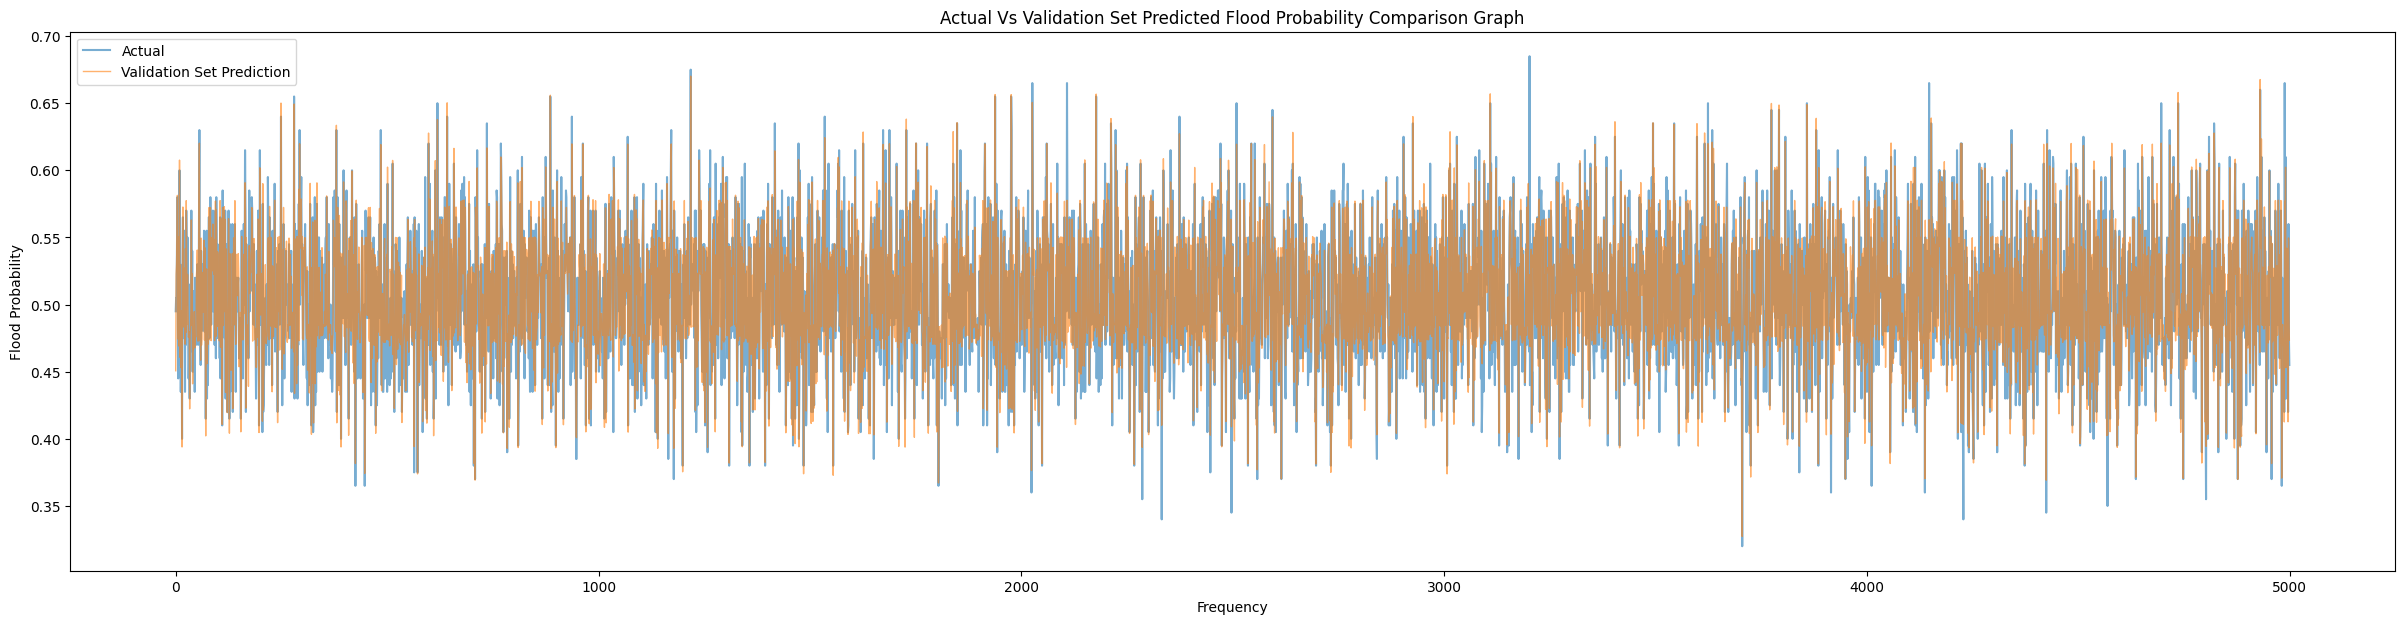

In [8]:
plt.figure(figsize=(30,7))
plt.plot(Y_val.values[:5000], alpha=0.6, label='Actual', linewidth=1.5)
plt.plot(val_pred[:5000], alpha=0.6, label='Validation Set Prediction', linewidth=1)
plt.legend()
plt.xlabel('Frequency')
plt.ylabel('Flood Probability')
plt.title('Actual Vs Validation Set Predicted Flood Probability Comparison Graph')
plt.show()

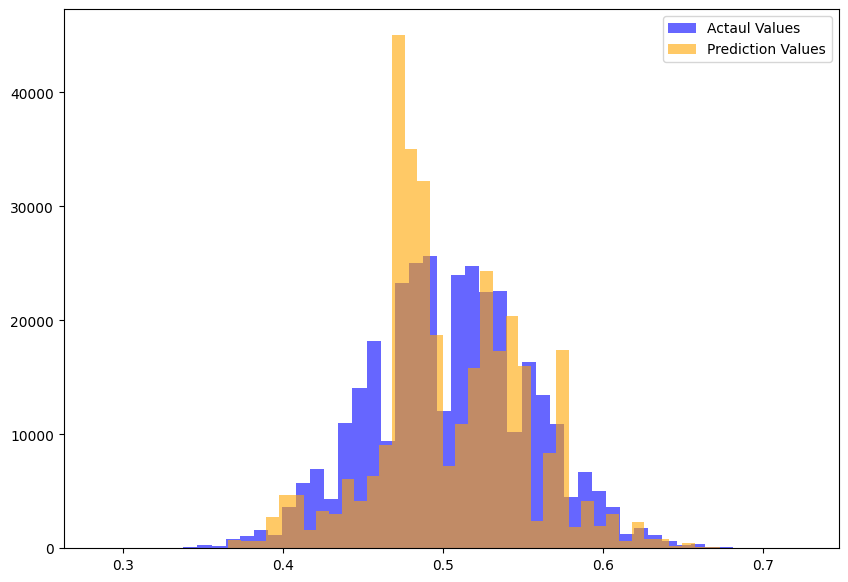

In [9]:
plt.figure(figsize=(10,7))
plt.hist(Y_val.values, bins=50, alpha=0.6, label='Actaul Values', color='blue')
plt.hist(val_pred, bins=50, alpha=0.6, label='Prediction Values', color='orange')
plt.legend()
plt.show()

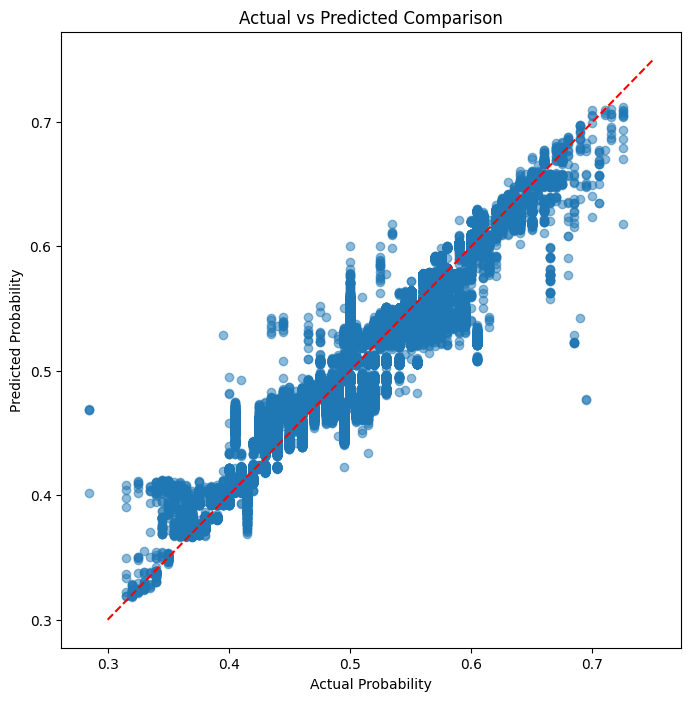

In [10]:
plt.figure(figsize=(8,8))
plt.scatter(Y_val, val_pred, alpha=0.5)
plt.plot([0.3, 0.75], [0.3, 0.75], color='red', linestyle='--') # Identity line
plt.xlabel('Actual Probability')
plt.ylabel('Predicted Probability')
plt.title('Actual vs Predicted Comparison')
plt.show()

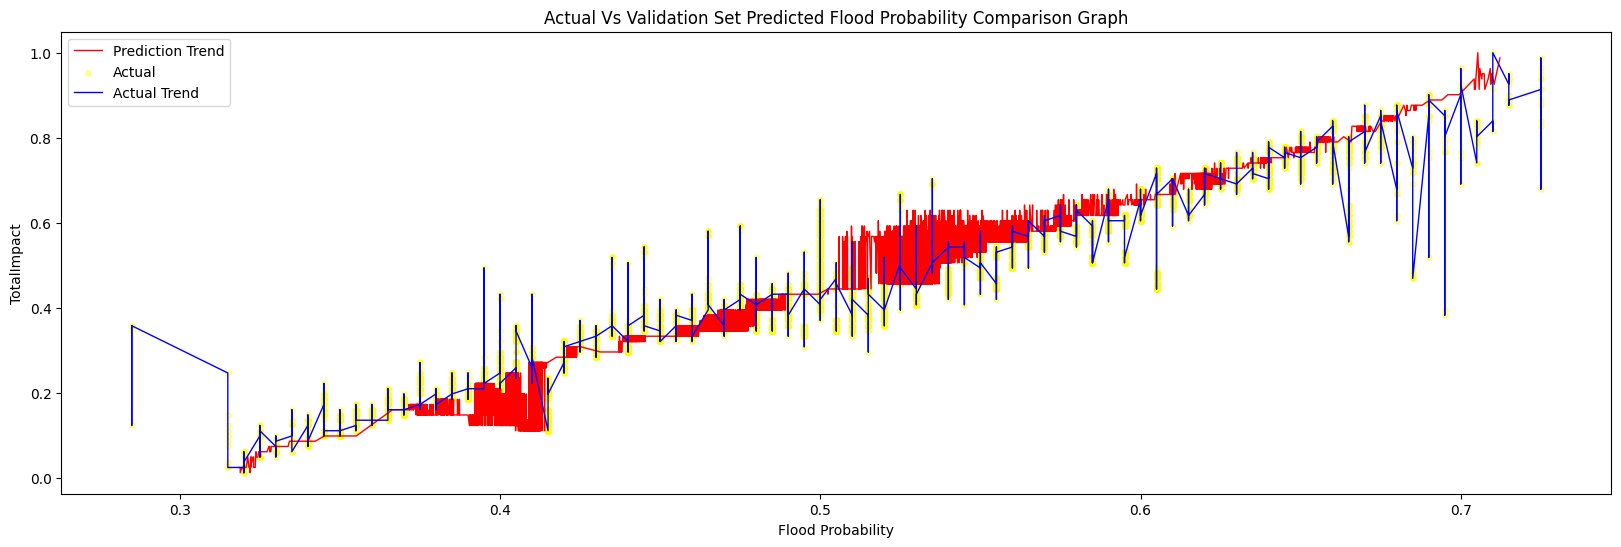

In [11]:
plt.figure(figsize=(20,6))
sort_idx = np.argsort(val_pred)

plt.plot(val_pred[sort_idx], X_val['TotalImpact'].iloc[sort_idx], color='red', label='Prediction Trend', linewidth=1)

plt.scatter(Y_val, X_val['TotalImpact'], alpha=0.4, label='Actual', s=14, color='yellow')

sort_idx = np.argsort(Y_val)
plt.plot(Y_val.iloc[sort_idx], X_val['TotalImpact'].iloc[sort_idx], color='blue', label='Actual Trend', linewidth=1)

plt.legend()
plt.xlabel('Flood Probability')
plt.ylabel('TotalImpact')
plt.title('Actual Vs Validation Set Predicted Flood Probability Comparison Graph')
plt.show()

# Saving model

In [12]:
import joblib

# ========== SAVING TRAINED MODELS ==========
print("Saving trained models...")

# Save base models dictionary
joblib.dump(models, 'base_models_final.pkl')
print("  Base models saved as 'base_models_final.pkl'")

# Save meta model
joblib.dump(meta_model_final, 'meta_model_final.pkl')
print("  Meta model saved as 'meta_model_final.pkl'")

print("\nModels saved successfully!")


Saving trained models...
  Base models saved as 'base_models_final.pkl'
  Meta model saved as 'meta_model_final.pkl'

Models saved successfully!


# Loading the saved model

In [ ]:
# ========== LOADING SAVED MODELS ==========
print("Loading saved models...")
base_models_final_loaded = joblib.load('base_models_final.pkl')
meta_model_final_loaded = joblib.load('meta_model_final.pkl')
print("Models loaded successfully!\n")

# ========== MAKING PREDICTIONS ON TEST DATA ==========
print("Making predictions on test data...")

# Step 1: Get predictions from all base models on test data
base_preds_test = {}
for name, model in base_models_final_loaded.items():
    print(f"  Predicting with {name}...")
    base_preds_test[name] = model.predict(test_input_df)

# Step 2: Stack base predictions into a DataFrame
stack_X_test = pd.DataFrame(base_preds_test)
print(f"\nStacked test predictions shape: {stack_X_test.shape}")
print(f"Columns: {stack_X_test.columns.tolist()}\n")

# Step 3: Get final predictions from meta model
final_predictions = meta_model_final_loaded.predict(stack_X_test)
print(f"Final predictions shape: {final_predictions.shape}")
print(f"Sample predictions: {final_predictions[:5]}\n")

# ========== CREATE SUBMISSION FILE ==========
print("Creating submission file...")
submission = pd.DataFrame({
    'id': test_df['id'],
    'FloodProbability': final_predictions
})

submission.to_csv('Rain_Prediction_submission_final.csv', index=False)
print("Submission saved as 'submission_stacking.csv'")
print(f"\nSubmission preview:\n{submission.head()}")


Loading saved models...
Models loaded successfully!

Making predictions on test data...
  Predicting with xgbr...
  Predicting with lgbmr...
  Predicting with catboost...
  Predicting with linearReg...
  Predicting with etr...
  Predicting with ridgeReg...

Stacked test predictions shape: (745305, 6)
Columns: ['xgbr', 'lgbmr', 'catboost', 'linearReg', 'etr', 'ridgeReg']

Final predictions shape: (745305,)
Sample predictions: [0.57802423 0.45626899 0.44935306 0.46716199 0.46729638]

Creating submission file...
Submission saved as 'submission_stacking.csv'

Submission preview:
        id  FloodProbability
0  1117957          0.578024
1  1117958          0.456269
2  1117959          0.449353
3  1117960          0.467162
4  1117961          0.467296
